loading libraries and data

In [1]:
import os
import glob
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd
from torchviz import make_dot
from IPython.display import Image, display
import optuna


# Configuration & Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cpu")
print(f"Running on: {device}")

DATASET_PATH = "ravdess_dataset"

# Emotion grouping & mapping
EMOTION_GROUPS = {
    "01": "neutral", "02": "neutral",
    "03": "positive", "08": "positive",
    "04": "negative", "05": "negative", "06": "negative", "07": "negative"
}

IDX_TO_LABEL = {0: "negative", 1: "neutral", 2: "positive"}
LABEL_TO_IDX = {"negative": 0, "neutral": 1, "positive": 2}



Running on: cpu


c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading audio and fature axtraction 

In [2]:
# Load audio paths & labels
audio_paths = []
labels = []

print("Loading audio files...")
for actor_folder in glob.glob(os.path.join(DATASET_PATH, "Actor_*")):
    for wav_file in glob.glob(os.path.join(actor_folder, "*.wav")):
        filename = os.path.basename(wav_file)
        parts = filename.split("-")
        if len(parts) < 3:
            continue
        emo_code = parts[2]
        if emo_code not in EMOTION_GROUPS:
            continue
        audio_paths.append(wav_file)
        labels.append(EMOTION_GROUPS[emo_code])

print(f"Found {len(audio_paths)} valid files")

y = np.array([LABEL_TO_IDX[lbl] for lbl in labels])
print(f"y shape: {y.shape}")

def extract_features(file_path, n_mfcc=20):
    y_audio, sr = librosa.load(file_path, sr=22050)
    y_audio, _ = librosa.effects.trim(y_audio)
    
    mfcc = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=n_mfcc)
    delta = librosa.feature.delta(mfcc)
    delta_delta = librosa.feature.delta(mfcc, order=2)
    
    return np.concatenate([
        np.mean(mfcc, axis=1),
        np.mean(delta, axis=1),
        np.mean(delta_delta, axis=1)
    ]).astype(np.float32)

print("Extracting features...")
X = np.array([extract_features(p) for p in audio_paths])
print(f"Original X shape: {X.shape}")

Loading audio files...
Found 1440 valid files
y shape: (1440,)
Extracting features...
Original X shape: (1440, 60)


data augmentation

In [3]:
def augment_features(feat):
    scale = np.random.uniform(0.95, 1.05)
    noise = np.random.normal(0, 0.01, feat.shape)
    return (feat * scale + noise).astype(np.float32)

augmented_X = np.array([augment_features(sample) for sample in X])

y_aug = np.concatenate([y, y])
X_aug = np.concatenate([X, augmented_X])

print("\nAugmentation complete:")
print(f"X_aug: {X_aug.shape}")
print(f"y_aug: {y_aug.shape}")

assert X_aug.shape[0] == y_aug.shape[0] == 2880, "Shape mismatch after augmentation!"



Augmentation complete:
X_aug: (2880, 60)
y_aug: (2880,)


converting labels to tensors

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug,
    test_size=0.20,
    random_state=SEED,
    stratify=y_aug
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Tensors
X_train_t = torch.from_numpy(X_train).float()
X_test_t = torch.from_numpy(X_test).float()
y_train_t = torch.from_numpy(y_train).long()
y_test_t = torch.from_numpy(y_test).long()

# Dataset & Loaders
class EmotionDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_ds = EmotionDataset(X_train_t, y_train_t)
test_ds = EmotionDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)


Models

In [5]:
class EmotionMLP(nn.Module):
    def __init__(self, input_dim=60, num_classes=3, dropout_rate=0.35):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(dropout_rate * 0.7),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(x)

class EmotionCNN(nn.Module):
    def __init__(self, num_classes=3, dropout_rate=0.35):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 15, 256), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

training

In [6]:
def train_model(model, name, epochs=50, lr=0.0008):
    print(f"\n{'═'*30} Training {name} {'═'*30}")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    
   
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5, verbose=True
    )
    
    best_acc = 0.0
    patience = 8
    counter = 0
    
    history = {'loss': [], 'acc': []}
    
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        history['loss'].append(avg_loss)
        
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out = model(Xb)
                pred = out.argmax(1)
                correct += (pred == yb).sum().item()
                total += yb.size(0)
        
        acc = 100.0 * correct / total
        history['acc'].append(acc)
        
        scheduler.step(acc)
        
        if epoch % 5 == 0 or epoch == epochs:
            print(f"Epoch {epoch:2d} | Loss: {avg_loss:.4f} | Val Acc: {acc:.2f}%")
        
        # Early Stopping
        if acc > best_acc:
            best_acc = acc
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping triggered at epoch {epoch}")
                break
 
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device)
            out = model(Xb)
            pred = out.argmax(1).cpu().numpy()
            y_pred.extend(pred)
            y_true.extend(yb.numpy())
    
    final_acc = accuracy_score(y_true, y_pred)
    print(f"\n{name} FINAL ACCURACY: {final_acc:.3%}")
    print(classification_report(y_true, y_pred, target_names=IDX_TO_LABEL.values(), digits=3))
    
    # Plots
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1); plt.plot(history['loss']); plt.title(f'{name} Loss')
    plt.subplot(1,2,2); plt.plot(history['acc'], c='orange'); plt.title(f'{name} Accuracy')
    plt.tight_layout(); plt.show()
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=IDX_TO_LABEL.values(), yticklabels=IDX_TO_LABEL.values())
    plt.title(f'{name} Confusion Matrix'); plt.show()
    
    return model, final_acc, history

optmization

In [7]:
def objective(trial):

    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    
    model = EmotionCNN(num_classes=3, dropout_rate=dropout).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
    
    best_acc = 0.0
    for epoch in range(1, 21): 
        model.train()
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(Xb)
            loss = nn.CrossEntropyLoss()(out, yb)
            loss.backward()
            optimizer.step()
        
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out = model(Xb)
                pred = out.argmax(1)
                correct += (pred == yb).sum().item()
                total += yb.size(0)
        
        acc = 100.0 * correct / total
        scheduler.step(acc)
        
        if acc > best_acc:
            best_acc = acc
    
    return best_acc


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10) 

print("Best hyperparameters:")
print(study.best_params)
print(f"Best validation accuracy: {study.best_value:.2f}%")

[I 2026-01-02 12:56:38,080] A new study created in memory with name: no-name-d18ff3a9-beb3-4a89-ba3b-1e882b002aa7
[I 2026-01-02 12:57:47,366] Trial 0 finished with value: 91.49305555555556 and parameters: {'lr': 0.00340228406001095, 'dropout': 0.4569570350257254}. Best is trial 0 with value: 91.49305555555556.
[I 2026-01-02 12:58:27,806] Trial 1 finished with value: 80.72916666666667 and parameters: {'lr': 2.1377585377990176e-05, 'dropout': 0.2314693265613495}. Best is trial 0 with value: 91.49305555555556.
[I 2026-01-02 12:59:48,721] Trial 2 finished with value: 91.49305555555556 and parameters: {'lr': 0.00028258905998793224, 'dropout': 0.46571036400995747}. Best is trial 0 with value: 91.49305555555556.
[I 2026-01-02 13:00:51,594] Trial 3 finished with value: 90.79861111111111 and parameters: {'lr': 0.0011789175391397786, 'dropout': 0.37692266143847797}. Best is trial 0 with value: 91.49305555555556.
[I 2026-01-02 13:01:29,813] Trial 4 finished with value: 90.45138888888889 and param

Best hyperparameters:
{'lr': 0.00022415257127991113, 'dropout': 0.17180959003306723}
Best validation accuracy: 91.84%


results


══════════════════════════════ Training MLP ══════════════════════════════


c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch  5 | Loss: 0.6005 | Val Acc: 68.23%
Epoch 10 | Loss: 0.4810 | Val Acc: 77.95%
Epoch 15 | Loss: 0.4241 | Val Acc: 81.94%
Epoch 20 | Loss: 0.3537 | Val Acc: 84.20%
Epoch 25 | Loss: 0.3310 | Val Acc: 87.50%
Epoch 30 | Loss: 0.2711 | Val Acc: 85.94%
Early stopping triggered at epoch 30

MLP FINAL ACCURACY: 85.938%
              precision    recall  f1-score   support

    negative      0.886     0.860     0.873       307
     neutral      0.780     0.896     0.834       115
    positive      0.877     0.831     0.853       154

    accuracy                          0.859       576
   macro avg      0.848     0.862     0.853       576
weighted avg      0.862     0.859     0.860       576



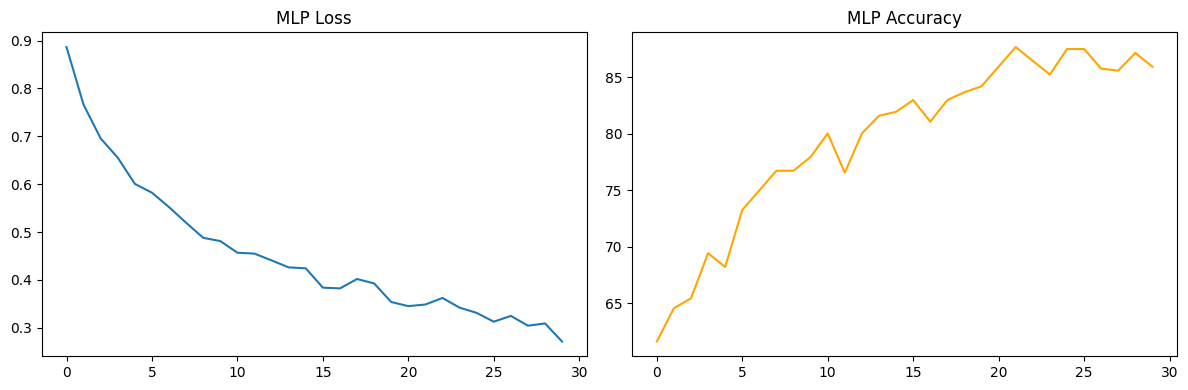

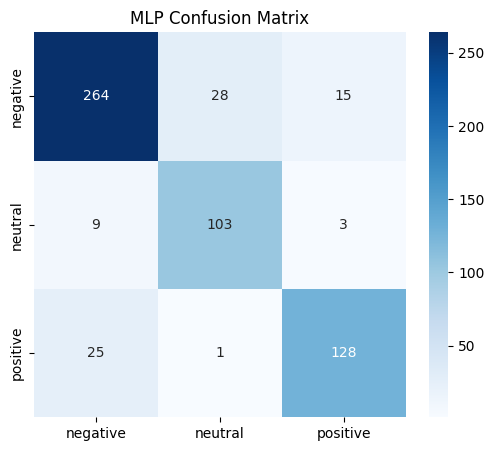


══════════════════════════════ Training CNN ══════════════════════════════


c:\Users\win10\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch  5 | Loss: 0.3189 | Val Acc: 83.51%
Epoch 10 | Loss: 0.1139 | Val Acc: 89.93%
Epoch 15 | Loss: 0.0332 | Val Acc: 92.36%
Epoch 20 | Loss: 0.1674 | Val Acc: 84.90%
Epoch 25 | Loss: 0.0099 | Val Acc: 93.40%
Epoch 30 | Loss: 0.0059 | Val Acc: 93.23%
Epoch 35 | Loss: 0.0030 | Val Acc: 93.40%
Early stopping triggered at epoch 36

CNN FINAL ACCURACY: 93.750%
              precision    recall  f1-score   support

    negative      0.951     0.941     0.946       307
     neutral      0.924     0.948     0.936       115
    positive      0.922     0.922     0.922       154

    accuracy                          0.938       576
   macro avg      0.932     0.937     0.935       576
weighted avg      0.938     0.938     0.938       576



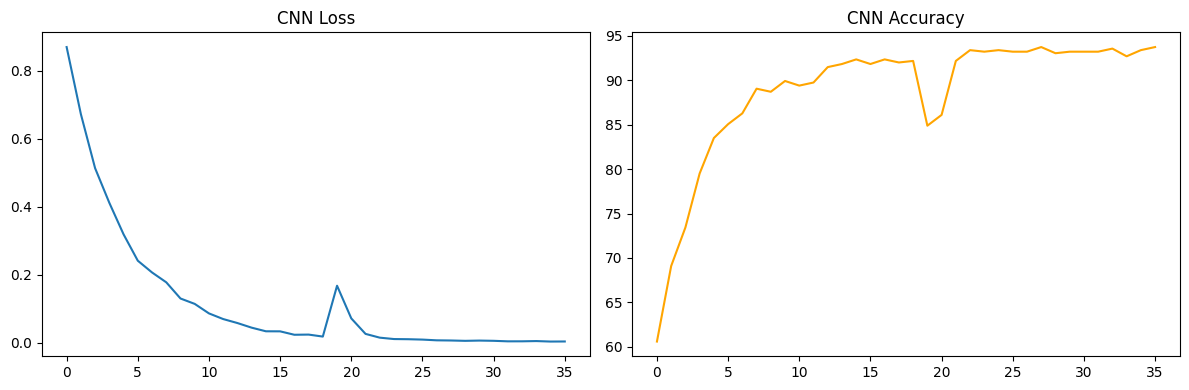

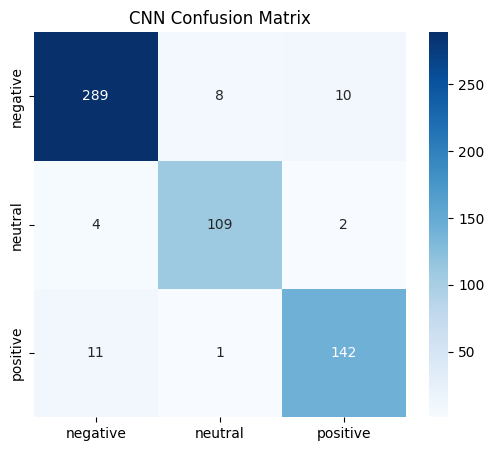

In [11]:
# Train MLP
mlp_model, mlp_acc, mlp_history = train_model(
    EmotionMLP(input_dim=60, num_classes=3, dropout_rate=0.35),
    "MLP",
    epochs=50,
    lr=0.0008
)

# Train CNN
cnn_model, cnn_acc, cnn_history = train_model(
    EmotionCNN(num_classes=3, dropout_rate=0.1718),
    "CNN",
    epochs=50,
    lr=0.000224
)

computational graph

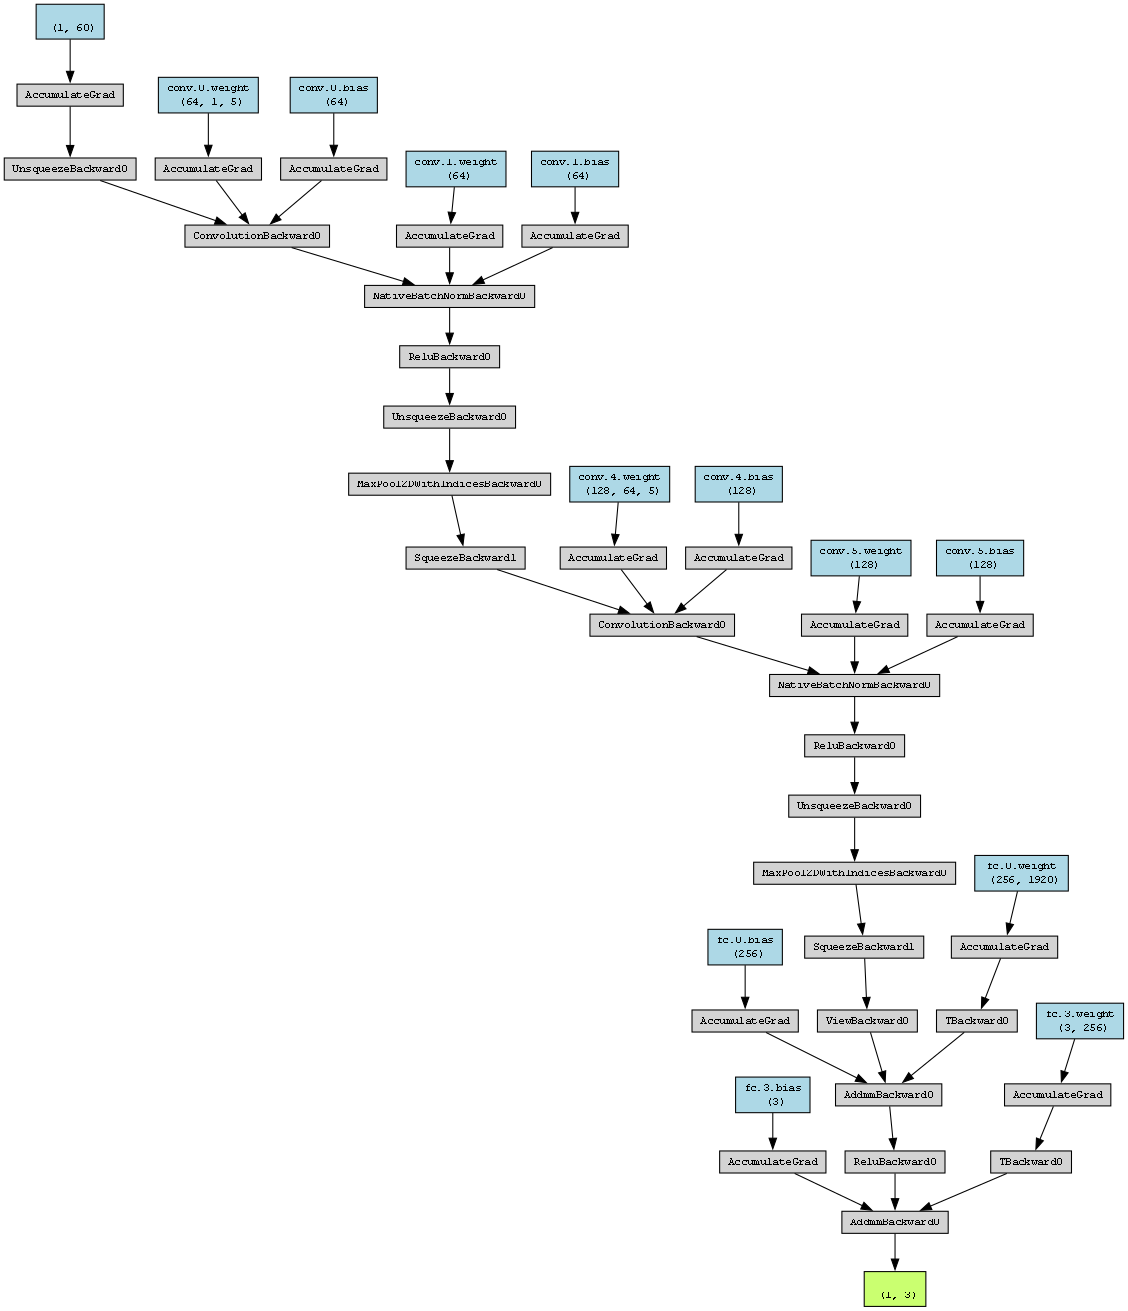

CNN Computational Graph displayed above!


In [9]:
from torchviz import make_dot
from IPython.display import Image, display

model = cnn_model 
dummy_input = torch.randn(1, 60, requires_grad=True).to(device)
output = model(dummy_input)

graph = make_dot(
    output,
    params=dict(model.named_parameters()),
    show_attrs=False,
    show_saved=False
)

graph.render("cnn_model_graph", format="png", cleanup=True)
display(Image(filename="cnn_model_graph.png"))
print("CNN Computational Graph displayed above!")

In [10]:
cnn_model.eval()

y_true, y_pred, y_conf = [], [], []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        outputs = cnn_model(X)
        probs = torch.softmax(outputs, dim=1)
        confs, preds = torch.max(probs, dim=1)
        
        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_conf.extend(confs.cpu().numpy())

y_true_labels = [IDX_TO_LABEL[i] for i in y_true]
y_pred_labels = [IDX_TO_LABEL[i] for i in y_pred]

df_predictions = pd.DataFrame({
    "Actual Emotion": y_true_labels,
    "Predicted Emotion": y_pred_labels,
    "Confidence": np.round(y_conf, 3),
    "Correct": [a == p for a, p in zip(y_true_labels, y_pred_labels)]
})

print("\nPREDICTIONS SAMPLE (first 15):")
print(df_predictions.head(15).to_string(index=False))

accuracy = accuracy_score(y_true, y_pred)
print(f"\nOVERALL ACCURACY: {accuracy:.3%}")

report = classification_report(y_true, y_pred, target_names=list(IDX_TO_LABEL.values()), digits=3, output_dict=True)
df_report = pd.DataFrame(report).transpose()
print("\nCLASSIFICATION REPORT:")
print(df_report.round(3).to_string())

cm = confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(cm, index=[f"Actual_{l}" for l in IDX_TO_LABEL.values()], columns=[f"Pred_{l}" for l in IDX_TO_LABEL.values()])
print("\nCONFUSION MATRIX:")
print(df_cm.to_string())

errors = df_predictions[~df_predictions["Correct"]]
print(f"\nERROR ANALYSIS: {len(errors)} misclassified ({len(errors)/len(df_predictions)*100:.1f}%)")
print(errors.head(10).to_string(index=False))

avg_conf = np.mean(y_conf)
correct_conf = np.mean([y_conf[i] for i in range(len(y_conf)) if y_pred[i] == y_true[i]])
wrong_conf = np.mean([y_conf[i] for i in range(len(y_conf)) if y_pred[i] != y_true[i]])
print("\nCONFIDENCE ANALYSIS:")
print(f"Avg confidence overall     : {avg_conf:.3f}")
print(f"Avg confidence (correct)   : {correct_conf:.3f}")
print(f"Avg confidence (wrong)     : {wrong_conf:.3f}")


PREDICTIONS SAMPLE (first 15):
Actual Emotion Predicted Emotion  Confidence  Correct
      negative          negative       1.000     True
      negative          negative       1.000     True
       neutral           neutral       0.997     True
      negative          negative       1.000     True
      negative          negative       0.984     True
      positive          positive       0.982     True
      negative          negative       0.999     True
      positive          positive       0.996     True
      negative          negative       1.000     True
      negative          negative       0.998     True
       neutral           neutral       0.998     True
      negative          positive       0.835    False
       neutral           neutral       1.000     True
      negative          negative       0.956     True
      negative          negative       1.000     True

OVERALL ACCURACY: 92.361%

CLASSIFICATION REPORT:
              precision  recall  f1-score  support
ne